In [2]:
import numpy as np
import torch
import crsData as crs
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

colors = ['b','g','darkred','c','mediumpurple','sienna']

%matplotlib inline

In [3]:
import crossSections as cross
filename = './crs/BSR.txt'
BSR = cross.multipleCrossSections(filename)

filename = './crs/TRINITI.txt'
TRINITI = cross.multipleCrossSections(filename)

# datasets
datasets = ["Biagi","BSR","Hayashi","IST-Lisbon","Morgan","Phelps","Puech","TRINITI","SIGLO"]
Nsets = len(datasets)

In [4]:
refs = ['Chutjian1981','Buckman1983','Filipovic2000a','Filipovic2000b','Khakoo2004','Tsurubuchi1996','Schappe1994','Li1988','Rapp1965','Straub1995','Wetzel1987','Mielewska2004','Panajotovic1997','Gibson1996','Srivastava1981','TonThat1977']
Nrefs = len(refs)
swarms, idx = [], 0
for ref in refs:
#     if (ref=='Tsurubuchi1996'):
#         continue
    filename = '../crs-exp/%s.txt' % ref
    swarms.append( crs.crsData(filename) )
    print(swarms[idx].ref)
    print(swarms[idx].variables)
    for dataType, dataset in swarms[idx].datasets.items():
        print(crs.typeDictI2S[dataType])
        print(dataset.variables)
        print(dataset.data)
    idx += 1


Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
{'E': ['eV', 'n/a', 'n/a'], 'crs': ['cm2', 'n/a', 'n/a'], 'crs-rms': ['%', 'n/a', 'n/a']}
Excitation, level 1
['E', 'crs', 'crs-rms']
[[1.6000e+01 4.1900e-22 1.2151e-22]
 [2.0000e+01 3.1900e-22 9.2510e-23]
 [3.0000e+01 1.6600e-22 4.8140e-23]
 [5.0000e+01 3.6100e-23 1.1913e-23]
 [1.0000e+02 5.6000e-24 2.6320e-24]]
Excitation, level 2
['E', 'crs', 'crs-rms']
[[1.6000e+01 3.9700e-22 1.1513e-22]
 [2.0000e+01 3.7000e-22 1.0730e-22]
 [3.0000e+01 4.5600e-22 1.3224e-22]
 [5.0000e+01 5.7800e-22 1.6762e-22]
 [1.0000e+02 3.2800e-22 9.5120e-23]]
Excitation, level 3
['E', 'crs', 'crs-rms']
[[1.6000e+01 6.0900e-23 2.0097e-23]
 [2.0000e+01 6.4400e-23 2.1252e-23]
 [3.0000e+01 4.5400e-23 2.1338e-23]
 [5.0000e+01 1.1200e-23 5.2640e-24]
 [1.0000e+02 5.4100e-24 2.5427e-24]]
Excitation, le

## Excitation 1s3 level

Chutjian, A., & Cartwright, D. C. (1981). Electron-impact excitation of electronic states in argon at incident energies between 16 and 100 eV. Physical Review A, 23(5), 2178–2193. https://doi.org/10.1103/PhysRevA.23.2178
True
16.0
Filipovic, D. M., Marinkovic, B. P., Pejcev, V., & Vuskovic, L. (2000). Electron-impact excitation of argon : II . The lowest resonance 4s[3/2]1 and metastable 4s[3/2]2 and 4s’[A1/2]0 states. Journal of Physics B: Atomic and Molecular and Optical Physics, 33, 2081–2094.
True
20.0
Khakoo, M. A., Vandeventer, P., Childers, J. G., Kanik, I., Fontes, C. J., Bartschat, K., Zeman, V., Madison, D. H., Saxena, S., Srivastava, R., & Stauffer, A. D. (2004). Electron impact excitation of the argon 3p54s configuration: Differential cross-sections and cross-section ratios. Journal of Physics B: Atomic, Molecular and Optical Physics, 37(1), 247–281. https://doi.org/10.1088/0953-4075/37/1/016
True
14.0
Schappe, R. S., Schulman, M. B., Anderson, L. W., & Lin, C. C. (1994). M

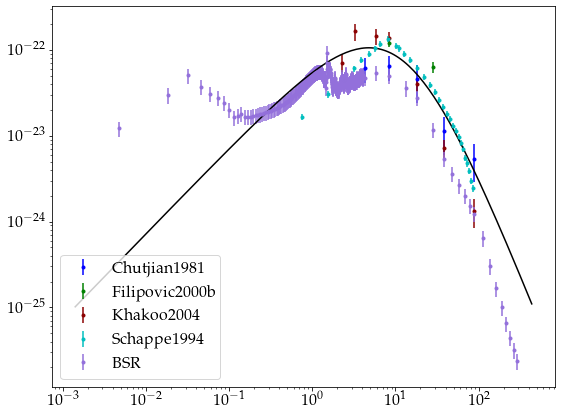

In [5]:
from models import *
level = 3
dataType = crs.typeDictS2I['Excitation, level '+str(level)]
threshold = np.floor(10*E_ext[level-1])/10.0


targetrefs = []

W = []
for k, swarm in enumerate(swarms):
    if dataType in swarm.datasets:
        targetrefs += [refs[k]]
        print(swarm.ref)
        print(swarm.datasets[dataType].error_provided)
        temp = np.copy(swarm.datasets[dataType].data)
        print(temp[0,0])
        W += [temp]
        
        filename = '%s.1s%d.txt' % (refs[k], 6-level)
        np.savetxt(filename, temp)
        
# Include BSR dataset, except the first entry (excitation level).
for c in BSR.crs:
    if ((c.colType==2) and (c.deltaE>threshold) and (c.deltaE<threshold+0.1)):
        targetrefs += ['BSR']
#         mask = c.data[:,0]>2.5e-1+E_ext[level-1]
#         temp = np.copy(c.data[mask,:])
        temp = np.copy(c.data[1:,:])
        error = temp[:,1][...,None] * 0.2
        temp = np.append( temp, error, axis=1)
        print(c.deltaE)
        print(np.count_nonzero(np.logical_and((temp[:,0]-E_ext[level-1]>np.exp(1)), (temp[:,0]-E_ext[level-1]<np.exp(3)))))
        W += [temp]
        
        filename = '%s.1s%d.txt' % ('BSR', 6-level)
        np.savetxt(filename, temp)

# mask = W[:,0] - E_ext[3] < 15.0
# W = W[mask,:]
# W = [W[-3]]
    
# theta_ref = np.array([10.4e0,2.0])
theta_ref = np.array([2.0e0,1.45])
Etest = np.linspace(-3.,3.,200)
Etest = 10.0 ** Etest + E_ext[level-1]
model0 = Excite_metastable(level,theta_ref,Etest)

temp = np.append(Etest[...,None], model0[...,None], axis=1)
filename = '%s.1s%d.naive.txt' % ('Bretagne', 6-level)
np.savetxt(filename, temp)

mask = model0 > 1.0e-25
Etest = Etest[mask]
model0 = model0[mask]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

plt.figure(1)
for k, Wk in enumerate(W):
#     if(k==4):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.plot(Etest-E_ext[level-1],model0,'-k')
plt.xscale('log')
plt.yscale('log')

# h = []
# for k, dataset in enumerate(datasets[:-2]):
#     if ((dataset=="Phelps") or (dataset=="Morgan")): continue
#     filename = "./crs/%s.txt" % dataset
#     tmp = cross.multipleCrossSections(filename)

#     for c in tmp.crs:
#         if ((c.colType==2) and (c.deltaE<11.6)):
# #         if ((c.colType==2) and (c.deltaE>11.8) and (c.deltaE<11.9)):
#             targetmf = np.copy(c.data[1:,:])
#             plt.loglog(targetmf[:,0] - E_ext[level-1],targetmf[:,1],'-')
#             h += [dataset]
# plt.title('Excitation 11.55eV')
plt.legend(loc="lower left")
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./dataset1.pdf", dpi=600)
# plt.savefig('./excitation.6.png',dpi=300)


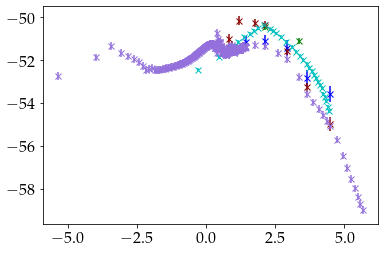

In [6]:
Wlog = []
for Wk in W:
    temp = np.copy(Wk)
    temp[:,0] = np.log(temp[:,0] - E_ext[level-1])
    temp[:,2] = np.log(1.0 + temp[:,2] / temp[:,1])
    temp[:,1] = np.log(temp[:,1])
    Wlog += [temp]

        
plt.figure(1)
for k, wlogk in enumerate(Wlog):
#     if((k>2)): continue
    plt.errorbar(wlogk[:,0],wlogk[:,1],yerr=wlogk[:,2],fmt='x',color=colors[k])
    
xd, yd, ed = [], [], []
xm = []
for wlogk in Wlog:
    temp = wlogk[:,0][:,None].repeat(len(wlogk),1)
    xd += [temp - temp.transpose()]
#     xm += [0.5*temp + 0.5*temp.t()]
    xm += [wlogk[:,0]]
    
    yd += [wlogk[:,1]]
    ed += [wlogk[:,2]]        

In [40]:
nParams = 2
nDatasets = len(Wlog)

from models import *
import scipy.sparse as sps
from scipy.linalg import cho_factor, cho_solve, LinAlgError

def log_prior(theta):
    setParams = np.reshape(theta[:(nDatasets * nParams)], [nDatasets, nParams])
    paramMeans = theta[(nDatasets * nParams):((nDatasets + 1) * nParams)]
    temp = theta[((nDatasets + 1) * nParams):]
    paramCov = np.zeros([nParams, nParams])
    idx = 0
    for k in range(nParams):
        length = nParams - k
        paramCov[k, k:] = temp[idx:(idx + length)]
        paramCov[k:, k] = paramCov[k, k:]
        idx += length

    theta_ref = np.array([10.4e0, 2.0])

    lp = 0.
    maxError = 1.0e2
    minError = 1.0e-2
    maxError = np.log(1.0 + maxError)
    minError = np.log(1.0 + minError)

    for s in range(nDatasets):
        if (setParams[s, 0] <= 0.0): return -np.inf
    if (paramMeans[0] <= 0.0): return -np.inf
    
    try:
        Lkb, low = cho_factor(paramCov)
    except LinAlgError:
        return - np.inf
    except:
        print(paramCov)
        raise RuntimeError('something else happened.')
    
    if ((paramMeans[0]<=0.0) or (paramMeans[1]<0.0)):
        return - np.inf
    if ((Lkb[0,0] <= 1.0e-3) or (Lkb[0,0] >=1.0e1)):
        return - np.inf
    if ((Lkb[1,1] <= 1.0e-3) or (Lkb[1,1] >=1.0e1)):
        return - np.inf

    sigma2 = ( 1.0 * theta_ref )**2
#     sigma2[0] *= 0.5
    lp = - 0.5 * np.sum( (paramMeans - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
    lp += - np.log(Lkb[0, 0]) - np.log(np.log(1e1) - np.log(1e-3))
    lp += - np.log(Lkb[1, 1]) - np.log(np.log(1e1) - np.log(1e-3))
#     lp += - np.log(theta[-1]) - np.log(np.log(1e1) - np.log(1e-3))
#     lp += - np.log(theta[-2]) - np.log(np.log(1e1) - np.log(1e-2))
    
#     for pk in range(nParams):
#         if (pk == 0):
#             dev = (np.log(theta_ref[pk]) - paramMeans[pk])
#         else:
#             dev = (np.log(theta_ref[pk]) - np.log(paramMeans[pk]))
#         lp += -0.5 * np.log(np.pi) - np.log(maxError) - 0.5 * (dev / maxError) ** 2
    
#     if (hyperParams[0, 0] <= 0.0):
#         return -np.inf
#     for pk in range(nParams):
#         if ((hyperParams[pk,1] > maxError) or (hyperParams[pk,1] < minError)):
#             return - np.inf
# #         lp += - np.log(hyperParams[pk,1]) - np.log(np.log(1e3) - np.log(1e-4))
#         if (pk == 0):
#             dev = (np.log(theta_ref[pk]) - hyperParams[pk, 0])
#         else:
#             dev = (np.log(theta_ref[pk]) - np.log(hyperParams[pk, 0]))
#         lp += -0.5 * np.log(np.pi) - np.log(maxError) - 0.5 * (dev / maxError) ** 2
        
    return lp

def log_likelihood(theta):
    # compute log-normal probability
    setParams = np.reshape(theta[:(nDatasets * nParams)], [nDatasets, nParams])
    paramMeans = theta[(nDatasets * nParams):((nDatasets + 1) * nParams)]
    temp = theta[((nDatasets + 1) * nParams):]
    paramCov = np.zeros([nParams, nParams])
    idx = 0
    for k in range(nParams):
        length = nParams - k
        paramCov[k, k:] = temp[idx:(idx + length)]
        paramCov[k:, k] = paramCov[k, k:]
        idx += length
#     paramCov = nptheta[((nDatasets + 1) * nParams):], [nParams, nParams])
#     hyperParams = np.reshape(theta[(nDatasets * nParams):], [nParams, 2])
#     print("hyperParams: ", hyperParams)
    
    try:
        Lkb, low = cho_factor(paramCov)
    except LinAlgError:
        return - np.inf
    except:
        print(paramCov)
        raise RuntimeError('something else happened.')
    
    lk = 0.0
    for k, Wlogk in enumerate(Wlog):
        dev = np.copy(setParams[k,:])
#         dev[0] = np.log(dev[0])
        dev -= paramMeans
        try:
            cov_inv_y = cho_solve((Lkb, low), dev)
        except:
            return - np.inf
        temp = -0.5 * np.sum(dev * cov_inv_y) - np.sum(np.log(Lkb.diagonal())) - 0.5 * nParams * np.log(2.0 * np.pi)
        lk += temp
#         for pk in range(nParams):
# #             dev = ((setParams[k,pk]) - hyperParams[pk, 0])
#             if (pk == 0):
#                 dev = (np.log(setParams[k,pk]) - hyperParams[pk, 0])
#             else:
#                 dev = ((setParams[k,pk]) - hyperParams[pk, 0])
#             lk += -0.5 * np.log(np.pi) - np.log(hyperParams[pk, 1]) - 0.5 * (dev / hyperParams[pk, 1]) ** 2
        logModel = np.log( Excite_metastable(level,setParams[k],W[k][:,0]) )
        dev = logModel - yd[k]
        temp = -0.5 * np.log(np.pi) - np.log(ed[k]) - 0.5 * (dev / ed[k]) ** 2
        lk += np.sum(temp)
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [41]:
import emcee
nwalkers = 32
# theta_ref = [10.4e0, 2.0] * len(Wlog) + [(10.4e0),10.4e-1,2.0,2.0e-1]
# theta_ref = [10.4e0, 2.0] * len(Wlog) + [np.log(10.4e0),np.log(2.0),(2.0),(2.0e-1)]
# theta_ref = [10.4e0, 2.0] * len(Wlog) + [np.log(10.4e0), 2.0] + [np.log(2.0),(0.0),(2.0e-1)]
theta_ref = [10.4e0, 2.0] * len(Wlog) + [(10.4e0), 2.0] + [(10.4e-1),(0.0),(2.0e-1)]
setParams_ref = np.reshape(theta_ref[:(nDatasets * nParams)], [nDatasets, nParams])
paramMeans_ref = theta_ref[(nDatasets * nParams):((nDatasets + 1) * nParams)]
temp = theta_ref[((nDatasets + 1) * nParams):]
paramCov_ref = np.zeros([nParams, nParams])
idx = 0
for k in range(nParams):
    length = nParams - k
    paramCov_ref[k, k:] = temp[idx:(idx + length)]
    paramCov_ref[k:, k] = paramCov_ref[k, k:]
    idx += length
print(setParams_ref)
print(paramMeans_ref)
print(paramCov_ref)
lkb, low = cho_factor(paramCov_ref)
print(lkb)
print(lkb.dot(lkb.T))
print(type(lkb))
# theta_ref = [10.4e0, 2.0] * len(Wlog) + [np.log(10.4e0),np.log(2.0),(2.0),(2.0e-1)]
# theta_ref = np.array([10.4e0,2.0,np.log(10.4e0),np.log(2.0),np.log(2.0),np.log(2.0)])
ndim = len(theta_ref)
# pos = theta_ref * (1.0 + 0.5 * np.random.randn(nwalkers,ndim) )
pos = theta_ref + 0.5 * np.random.randn(nwalkers,ndim)
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

[[10.4  2. ]
 [10.4  2. ]
 [10.4  2. ]
 [10.4  2. ]
 [10.4  2. ]]
[10.4, 2.0]
[[1.04 0.  ]
 [0.   0.2 ]]
[[1.0198039 0.       ]
 [0.        0.4472136]]
[[1.04 0.  ]
 [0.   0.2 ]]
<class 'numpy.ndarray'>


In [42]:
sampler.run_mcmc(pos, 1);

nBatch = 10000
nIter = 9
for k in range(nIter):
    sampler.run_mcmc(None, nBatch, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print("correlation time over sample size: %.5f" % (np.amax(tau) / sampler.backend.iteration))

  9%|██████████████▊                                                                                                                                                           | 872/10000 [00:03<00:39, 231.00it/s]/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_90566/110353343.py:118: RuntimeWarning: invalid value encountered in log
  logModel = np.log( Excite_metastable(level,setParams[k],W[k][:,0]) )
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:36<00:00, 276.49it/s]


correlation time over sample size: 0.12567


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:35<00:00, 280.30it/s]


correlation time over sample size: 0.12058


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:35<00:00, 284.28it/s]


...

correlation time over sample size: 0.06775


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:35<00:00, 284.59it/s]


correlation time over sample size: 0.06268


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:35<00:00, 279.96it/s]


correlation time over sample size: 0.05773


(6240, 15)
(6240,)
(101, 101)
0.006605617726792565
0.006604768460163841


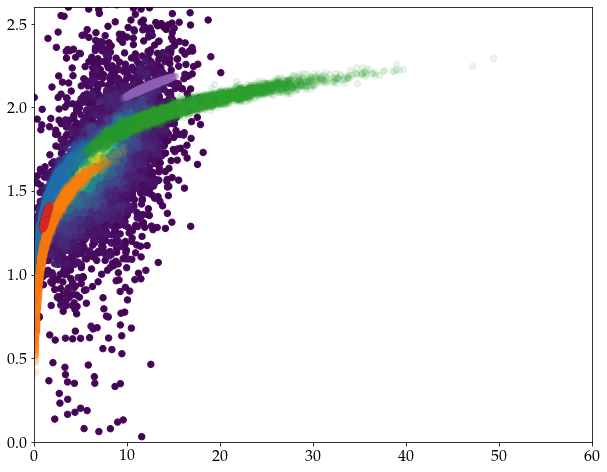

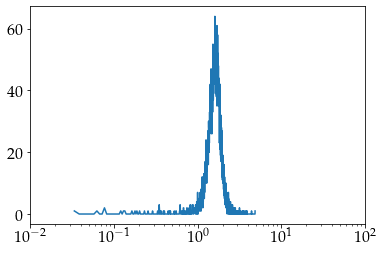

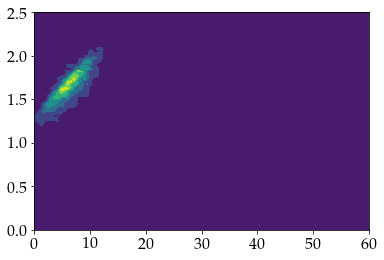

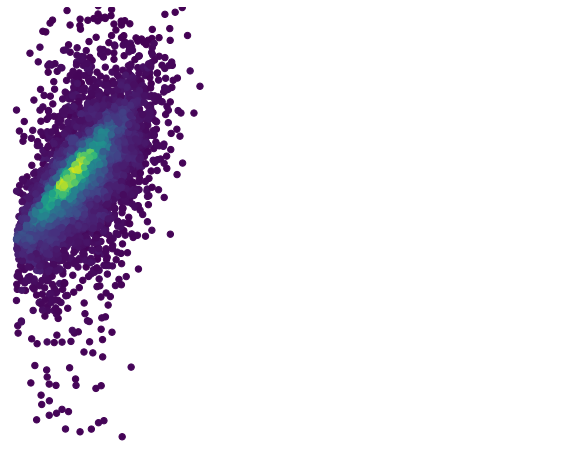

In [51]:
nTotal = (nDatasets + 1) * nParams + int(nParams * (nParams+1) / 2)
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)

# tmp = flat_samples
# tmp.tofile('../crs-Bayes-2level/crs.excitation.1s3.normal_scale.dat')
# flat_samples = np.fromfile('../crs-Bayes-2level/crs.excitation.1s3.normal_scale.dat')
# flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/nTotal), nTotal])

# # flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# # flat_samples = sampler.get_chain(flat=True)
# # mask = flat_samples[:,0]>0.0
# # flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

from interp import histogram_weight_2d
Nx = 100
# xlim = [np.log(1e-3), np.log(1e5)]
xlim = [0., 60.]
ylim = [0.0, 2.5]
histw, wgk = histogram_weight_2d(flat_samples[:,-5],flat_samples[:,-4],Nx,Nx,xlim,ylim)
print(histw.shape)
print(wgk.shape)
print(np.amax(wgk))
print(np.amax(histw))

hype = np.copy(flat_samples)
hypehistw = np.copy(histw)

plt.figure(1)
plt.scatter((flat_samples[:,-5]), flat_samples[:,-4],s=40.0, c=histw)
for k in range(len(Wlog)):
    plt.scatter(flat_samples[:,2*k], flat_samples[:,2*k+1],s=40.0,alpha=0.1)
# plt.scatter(np.exp(flat_samples[:,-5]), flat_samples[:,-4],s=0.6, c=histw, alpha=0.1)
# plt.scatter((flat_samples[:,-5]), flat_samples[:,-4],s=1.0, c=histw, alpha=0.1)
# plt.xscale('log')
plt.xlim([0.0, 60])
plt.ylim([0.0, 2.6])
# fig = corner.corner(flat_samples);
# plt.semilogx(flat_samples[:,0], flat_samples[:,1],'.')
# mask = np.logical_and((flat_samples[:,2] > 0), (flat_samples[:,2] < 1e82))
# mask = (flat_samples[:,2] > 0)
# plt.loglog(flat_samples[mask,2], flat_samples[mask,3],'.')
# plt.plot(flat_samples[:,2], flat_samples[:,3],'.')
# plt.loglog(np.exp(flat_samples[:,2]), np.exp(flat_samples[:,3] - 1.0),'.')
# plt.semilogx(np.exp(flat_samples[:,-4]), np.exp(flat_samples[:,-2]),'.')
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)
fig = plt.gcf()
fig.set_size_inches(10, 8)
# fig.savefig("./1s3.hyper.scatter.pdf", dpi=600, bbox_inches='tight')

hist, bin_edges = np.histogram(flat_samples[:,-4], bins=1000)
xg = 0.5 * (bin_edges[:-1] + bin_edges[1:])
plt.figure(2)
# plt.semilogx(np.exp(xg), hist,'-')
# plt.xlim([1e-2, 1e6])
plt.semilogx((xg), hist,'-')
plt.xlim([1e-2, 1e2])


# Nx = 100
# xg = np.exp(np.linspace(xlim[0], xlim[1], Nx+1))
xg = (np.linspace(xlim[0], xlim[1], Nx+1))
yg = np.linspace(ylim[0], ylim[1], Nx+1)
Xg, Yg = np.meshgrid(xg, yg)
# Pg = np.zeros(Xg.shape)
# for k in range(flat_samples.shape[0]):
#     xlogmean = flat_samples[k,-4]
#     xlogstd = flat_samples[k,-3]
#     ymean = flat_samples[k,-2]
#     ystd = flat_samples[k,-1]
#     Pk = 1.0 / np.sqrt(np.pi) / xlogstd * np.exp(-0.5 * (((Xg) - xlogmean) / xlogstd) ** 2)
#     Pk *= 1.0 / np.sqrt(np.pi) / ystd * np.exp(-0.5 * ((Yg - ymean) / ystd) ** 2)
#     Pg += Pk
# Pg /= flat_samples.shape[0]

plt.figure(3)
plt.contourf(Xg, Yg, wgk.T)
# for k in range(len(Wlog)):
#     plt.scatter(flat_samples[:,2*k], flat_samples[:,2*k+1],s=3, alpha=0.05)
# plt.xscale('log')
# plt.xlim([0, 60])
# plt.ylim([0, 2.5])

plt.figure(6)
plt.scatter((flat_samples[:,-5]), flat_samples[:,-4],s=40.0, c=histw)
plt.xlim([-1, 60])
plt.ylim([0, 2.7])
plt.clim(0, 6.7e-3)
plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
fig.savefig("./1s3.hyper-param.scatter.pdf", dpi=600, bbox_inches='tight')

6240


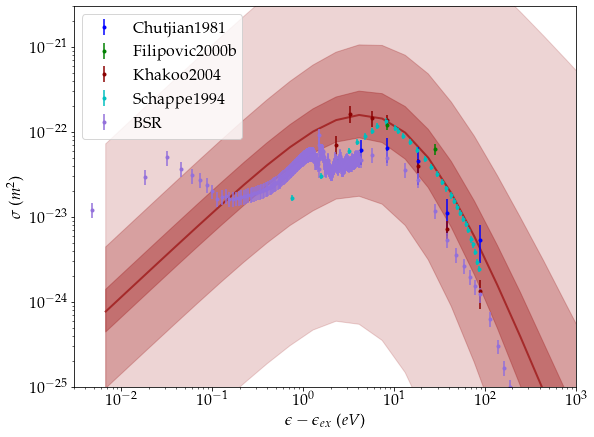

In [52]:
nTotal = (nDatasets + 1) * nParams + int(nParams * (nParams+1) / 2)
flat_samples = np.fromfile('../crs-Bayes-2level/crs.excitation.1s3.normal_scale.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/nTotal), nTotal])

# tt = len(W)
# mask = np.logical_and(flat_samples[:,(2*tt+1)] > 1.5, flat_samples[:,(2*tt+1)] < 2.0)
# flat_samples = flat_samples[mask]

Nsample = len(flat_samples)
print(Nsample)
sig1 = int(0.5 * (1.0 - 0.68) * Nsample)
sig2 = int(0.5 * (1.0 - 0.95) * Nsample)
sig3 = int(0.5 * (1.0 - 0.997) * Nsample)
median = int(0.5 * Nsample)

Nw = 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
modelSamples = np.zeros([Nsample, Nw])

inds = np.random.randint(len(flat_samples), size=Nsample)
for k, ind in enumerate(inds):
    sample = flat_samples[ind]
#     modelSamples[k] = Excite_metastable(level,sample[-5:-3],Etest)
    tt = len(W)
    modelSamples[k] = Excite_metastable(level,sample[2*tt:(2*tt+2)],Etest)
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=0.1)

modelSamples.sort(axis = 0)

plt.loglog(Etest - E_ext[level-1], modelSamples[median,:],'-', color='brown', linewidth=2.0)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig3,:], modelSamples[sig3,:], color='brown', alpha=0.2)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig2,:], modelSamples[sig2,:], color='brown', alpha=0.3)
plt.fill_between(Etest - E_ext[level-1], modelSamples[-sig1,:], modelSamples[sig1,:], color='brown', alpha=0.4)

# nominal = Excite_metastable(level,mean_1s3,Etest)
# mask = nominal > 1.0e-25
# plt.plot(Etest[mask]-E_ext[level-1], nominal[mask], "b-", linewidth=2.0)
    
for k, Wk in enumerate(W):
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.2level.pdf", dpi=1200)

filename = '../crs-Bayes-2level/post-process/excitation.1s3.intervals.txt'
data = np.array([Etest, modelSamples[median,:], modelSamples[-sig1,:], modelSamples[sig1,:],
                                                modelSamples[-sig2,:], modelSamples[sig2,:],
                                                modelSamples[-sig3,:], modelSamples[sig3,:]]).T
np.savetxt(filename, data)

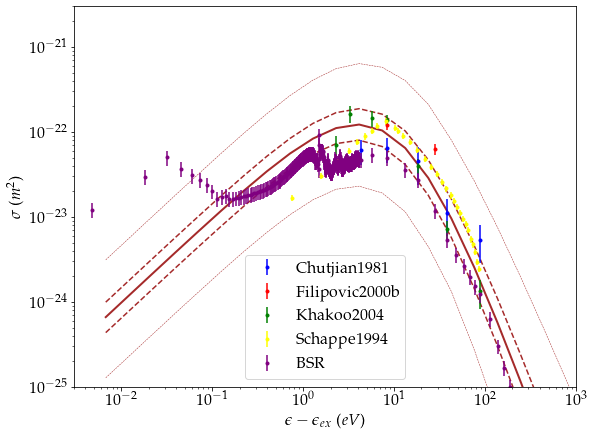

In [88]:
flat_samples = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
flat_samples = np.reshape(flat_samples, [int(len(flat_samples)/4), 4])

Nsample, Nw = flat_samples.shape[0], 25
wtest = np.linspace(-5,9.,Nw)
Etest = np.exp(wtest) + E_ext[level-1]
sample_curves = np.zeros([Nsample, Nw])
sig1 = int(np.floor(Nsample * 0.5 * (1.0 - 0.68)))
sig3 = int(np.floor(Nsample * 0.5 * (1.0 - 0.997)))
median = int(np.floor(Nsample * 0.5))

for ind in range(Nsample):
    sample = flat_samples[ind]
    models = Excite_metastable(level,sample[:2],Etest)
    sample_curves[ind,:] = models

sample_sort = np.copy(sample_curves)
sample_sort.sort(axis=0)

plt.figure(1)
plt.loglog(Etest-E_ext[level-1], sample_sort[sig1,:], '--', linewidth=1.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[-sig1,:], '--', linewidth=1.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[sig3,:], '--', linewidth=0.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[-sig3,:], '--', linewidth=0.5, color='brown')
plt.loglog(Etest-E_ext[level-1], sample_sort[median,:], '-', linewidth=2.0, color='brown')
    
#     mask = models > 1.0e-25
#     plt.plot(Etest[mask]-E_ext[level-1], models[mask], "C1", alpha=1)
# plt.plot(W[:,0]-E_ext[3],W[:,1],'x')
# plt.errorbar(W[:,0]-E_ext[3],W[:,1],yerr=W[:,2],fmt='.')
for k, Wk in enumerate(W):
#     if((k!=4)): continue
#     if(k==3):
#         plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
#     else:
    plt.errorbar(Wk[:,0]-E_ext[level-1],Wk[:,1],yerr=Wk[:,2],fmt='.',color=colors[k],label=targetrefs[k])
#     plt.plot(Wk[:,0]-E_ext[level-1],Wk[:,1],'.',color=colors[k],label=targetrefs[k])
# plt.loglog(np.sort(W[:,0])-E_ext[3],model0,'-k')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\epsilon-\epsilon_{ex}$ ($eV$)')
plt.ylabel('$\sigma$ ($m^2$)')
plt.ylim([1e-25, 3e-21])
plt.xlim([3e-3, 1e3])
plt.legend()
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.show()
# fig.savefig("./excitation.1s3.curve.pdf", dpi=1200)

temp = np.zeros([Nw,6])
temp[:,0] = Etest
temp[:,1] = sample_sort[median,:]
temp[:,2] = sample_sort[sig1,:]
temp[:,3] = sample_sort[-sig1,:]
temp[:,4] = sample_sort[sig3,:]
temp[:,5] = sample_sort[-sig3,:]
filename = './1s%d.sample_crs.txt' % ((6-level))
np.savetxt(filename, temp)

### MCMC sampling on each dataset

In [78]:
from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    theta_ref = np.array([10.4e0, 2.0])
    sigma2 = ( 1.0 * theta_ref )**2
    lp = - 0.5 * np.sum( (theta[:2] - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
        
    return lp


def log_likelihood(theta):
    lk = 0.0
    for k in range(len(Wlog)):
#         if (k!=4): continue
            
        logModel = np.log( Excite_metastable(level,theta[:2],W[k][:,0]) )
        dev = logModel - yd[k]
        lk += - 0.5 * np.sum(dev * dev / ed[k] / ed[k])
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [79]:
import emcee
nwalkers = 32
theta_ref = np.array([10.4e0,2.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [81]:
# sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 314.62it/s]


[39.99963136 47.90687254]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 314.52it/s]


[39.96414447 47.66936935]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 305.96it/s]


...

[39.88872592 46.78301612]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 320.23it/s]


[39.90076065 46.73061505]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:01<00:00, 296.94it/s]


[39.88953915 46.66754555]


(16672, 2)


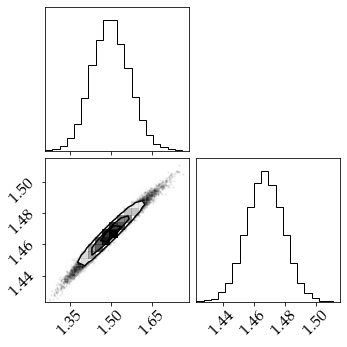

In [83]:
flat_samples = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
# flat_samples = sampler.get_chain(discard=200, thin=50, flat=True)
# flat_samples = sampler.get_chain(flat=True)
# mask = flat_samples[:,0]>0.0
# flat_samples = flat_samples[mask,:]
print(flat_samples.shape)

tmp = flat_samples
tmp.tofile('../crs-Bayes-individual/All.1s3.dat')

import corner

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

fig = corner.corner(flat_samples);
# fig.savefig("./excitation.1s2.attempt2.corner.pdf", dpi=1200)

0.029082511505437867
0.029593990284485217
0.015184125212878829
0.2392622379544344
0.15218935404731693
0.3039988246528539
0.00413633309626093


/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_65580/4106561373.py:70: UserWarning: Trying to register the cmap 'BlueAlphaMap' which already exists.
  plt.register_cmap(cmap=blueMap)


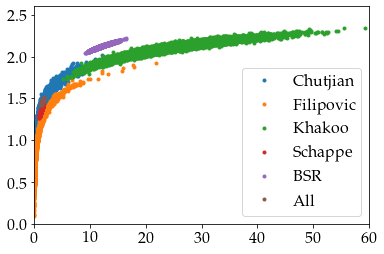

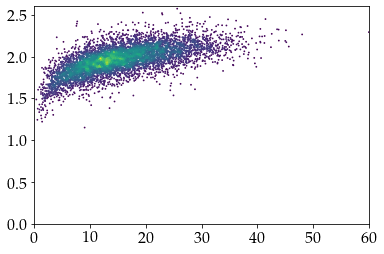

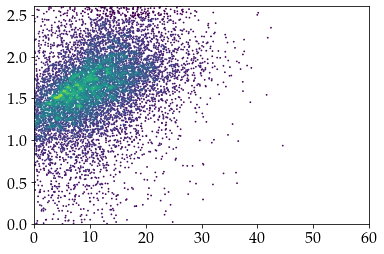

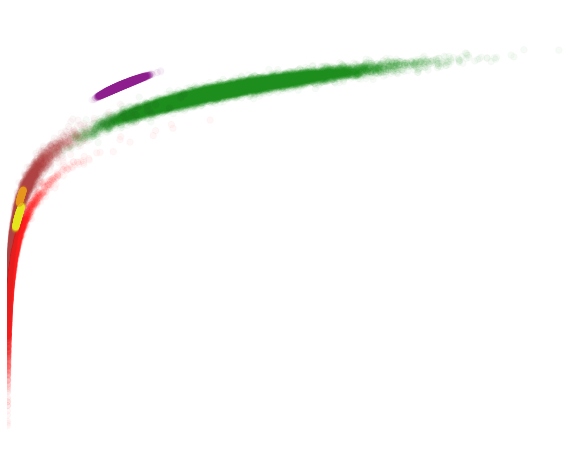

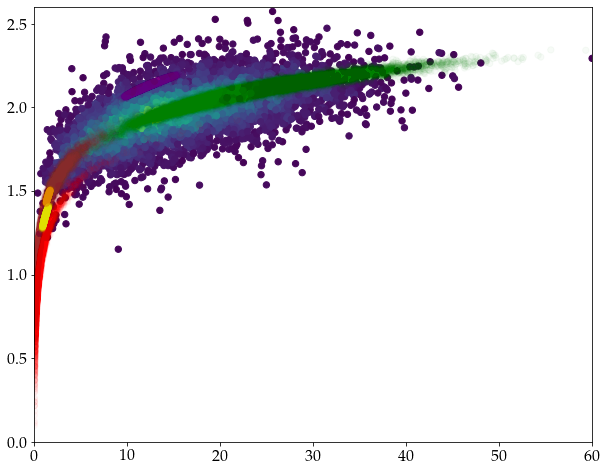

In [252]:
from interp import histogram_weight_2d
names = ['Chutjian','Filipovic','Khakoo','Schappe','BSR','All']

xlim = [0.0, 60.0]
ylim = [0.0, 2.5]
Nx, Ny = 100, 100
xg = np.linspace(xlim[0],xlim[1],Nx+1)
yg = np.linspace(ylim[0],ylim[1],Ny+1)

YG, XG = np.meshgrid(yg,xg)

flat_samples = []
wg = []
for k in range(6):
    temp = np.fromfile('../crs-Bayes-individual/%s.1s3.dat' % names[k])
    temp = np.reshape(temp, [int(len(temp)/2), 2])
    histw, wgk = histogram_weight_2d(temp[:,0],temp[:,1],Nx,Ny,xlim,ylim)
    wg += [np.copy(wgk)]
    temp = np.append(temp, histw[...,None], axis=1)
    flat_samples += [temp]
    
gpr_sample = np.fromfile('../crs-Bayes-gpr/without-swarm/crs.excitation.1s3.dat')
gpr_sample = np.reshape(gpr_sample, [int(len(gpr_sample)/4), 4])
histw, wgk = histogram_weight_2d(gpr_sample[:,0],gpr_sample[:,1],Nx,Ny,xlim,ylim)
wg += [np.copy(wgk)]
gpr_sample = np.append(gpr_sample, histw[...,None], axis=1)
    
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})
plt.figure(1)
# plt.plot(gpr_sample[:,0], gpr_sample[:,1],'.')
for k in range(6):
    print(np.amax(flat_samples[k][:,2]))
#     plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=0.4, c=flat_samples[k][:,2],label=names[k])
    plt.plot(flat_samples[k][:,0], flat_samples[k][:,1],'.',label=names[k])
plt.xlim([0, 60])
plt.ylim([0, 2.6])
plt.legend()

print(np.amax(gpr_sample[:,4]))
plt.figure(2)
plt.scatter(gpr_sample[:,0], gpr_sample[:,1],s=0.6, c=gpr_sample[:,4])
plt.xlim([0, 60])
plt.ylim([0, 2.6])

# for k in range(6):
#     print(flat_samples[k].shape)
#     filename = '%s.1s3.param.txt' % (names[k])
#     np.savetxt(filename, flat_samples[k])
    
# gpr_data = gpr_sample[:,[0,1,4]]
# filename = 'GPR.1s3.param.txt'
# np.savetxt(filename, gpr_data)

blueDict = {'red': ((0.0, 0.0, 0.0),
                    (1.0, 0.0, 0.0)),
            'green': ((0.0, 0.0, 0.0),
                      (1.0, 0.0, 0.0)),
            'blue': ((0.0, 1.0, 1.0),
                     (1.0, 1.0, 1.0)),
            'alpha': ((0.0, 0.01, 0.01),
                      (1.0, 0.01, 0.01))
           }
from matplotlib.colors import LinearSegmentedColormap, to_rgba
blueMap = LinearSegmentedColormap('BlueAlphaMap', blueDict)
plt.register_cmap(cmap=blueMap)

plt.figure(3)
plt.scatter((hype[:,-5]), hype[:,-4],s=0.6, c=hypehistw)
plt.xlim([0, 60])
plt.ylim([0, 2.6])
# plt.figure(3)
# plt.pcolor(XG,YG,wg[-1],edgecolor='none',cmap='BlueAlphaMap')
# # plt.pcolor(XG,YG,np.ones([Nx+1,Ny+1]),alpha=wg[-1]/np.amax(wg[-1]),edgecolor='none')
# plt.axis('off')
# fig = plt.gcf()
# fig.set_size_inches(10, 8)
# # fig.savefig("./1s3.gpr.pdf", dpi=600, bbox_inches='tight')
# # fig.savefig("./1s3.gpr.png", dpi=600, bbox_inches='tight')

# colors = ['brown','red','green','yellow','purple','orange']
# for k in range(6):
#     colork = to_rgba(colors[k])
#     cDict = {'red': ((0.0, colork[0], colork[0]),
#                      (1.0, colork[0], colork[0])),
#              'green': ((0.0, colork[1], colork[1]),
#                        (1.0, colork[1], colork[1])),
#              'blue': ((0.0, colork[2], colork[2]),
#                       (1.0, colork[2], colork[2])),
# #              'alpha': ((0.0, 0.006, 0.006),
# #                        (1.0, 0.006, 0.006))
#              'alpha': ((0.0, 0.03, 0.03),
#                        (1.0, 0.03, 0.03))
#             }
#     cMap = LinearSegmentedColormap('colorMap%d' % k, cDict)
#     plt.register_cmap(cmap=cMap)
    
# plt.figure(4)
# for k in range(6):
#     plt.pcolor(XG,YG,wg[k],edgecolor='none',cmap='colorMap%d' % k)
# plt.axis('off')
# fig = plt.gcf()
# fig.set_size_inches(10, 8)
# # fig.savefig("./1s3.naive.pdf", dpi=600, bbox_inches='tight')

plt.figure(5)
for k in range(6):
    plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0, c=flat_samples[k][:,2],label=names[k], cmap='colorMap%d' % k)
#     plt.plot(flat_samples[k][:,0], flat_samples[k][:,1],'.',label=names[k])
plt.xlim([0, 60])
plt.ylim([0, 2.6])
plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
# fig.savefig("./1s3.naive.scatter.pdf", dpi=600, bbox_inches='tight')

plt.figure(6)
plt.scatter(gpr_sample[:,0], gpr_sample[:,1],s=40.0, c=gpr_sample[:,4])#, cmap='BlueAlphaMap')
for k in range(6):
    plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0, c=flat_samples[k][:,2],label=names[k], cmap='colorMap%d' % k)
# plt.pcolor(XG,YG,wg[-1],edgecolor='none',cmap='BlueAlphaMap')
# plt.pcolor(XG,YG,np.ones([Nx+1,Ny+1]),alpha=wg[-1]/np.amax(wg[-1]),edgecolor='none')
plt.xlim([0, 60])
plt.ylim([0, 2.6])
# plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)
# fig.savefig("./1s3.gpr.scatter.pdf", dpi=600, bbox_inches='tight')

## GP-approach

In [297]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
#     if ((theta[0]<=0.0) or (theta[1]<0.0)):
#         return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e2) or (theta[-1]>=1e2)):
        return - np.inf
    theta_ref = np.array([np.log(10.4e0), 2.0])
    sigma = np.array([np.log(1.0 + 10.0), 2.0])

    lp = 0.0
    lp += -0.5 * ((theta[0]) - (theta_ref[0]))**2 / sigma[0] / sigma[0] - 0.5 * np.log(2.0 * np.pi) - np.log(sigma[0])
    lp += -0.5 * ((theta[1]) - (theta_ref[1]))**2 / sigma[1] / sigma[1] - 0.5 * np.log(2.0 * np.pi) - np.log(sigma[1])
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        modelParam = np.array([np.exp(theta[0]), theta[1]])
        logModel = np.log( Excite_metastable(level,modelParam,W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [292]:
from torch_kernel import *
# cov_kern = ExpKernelPack(1,requires_grad=False)
cov_kern = MaternPack(1,requires_grad=False)
print(cov_kern.var[0].dtype, cov_kern.scale[0].dtype)

from models import *

def log_prior(theta):
    if ((theta[0]<=0.0) or (theta[1]<0.0)):
        return - np.inf
    if ((theta[-2]<=1.0e-2) or (theta[-1]<=1.0e-3) or (theta[-2]>=1e1) or (theta[-1]>=1e1)):
        return - np.inf
    theta_ref = np.array([(10.4e0), 2.0])
    sigma = np.array([np.log(1.0 + 1.0), 2.0])

    lp = 0.0
    lp += -0.5 * (np.log(theta[0]) - np.log(theta_ref[0]))**2 / sigma[0] / sigma[0] - 0.5 * np.log(2.0 * np.pi) - np.log(sigma[0])
    lp += -0.5 * ((theta[1]) - (theta_ref[1]))**2 / sigma[1] / sigma[1] - 0.5 * np.log(2.0 * np.pi) - np.log(sigma[1])
        
    return lp


def log_likelihood(theta):
    # compute log-normal probability
    cov_kern.var[0], cov_kern.scale[0] = theta[-2:]
    
    lk = 0.0
    for k in range(len(Wlog)):
        cov = cov_kern.forward(0,torch.tensor(xd[k]))
        cov += torch.diag(torch.tensor(ed[k]**2))
        try:
            LKb = torch.linalg.cholesky(cov)
        except RuntimeError:
            return - np.inf
            
        modelParam = np.array([(theta[0]), theta[1]])
        logModel = np.log( Excite_metastable(level,modelParam,W[k][:,0]) )
        dev = logModel - yd[k]
        dev = torch.tensor(dev)
        cov_inv_y = torch.cholesky_solve(dev.reshape(dev.size(0),1),LKb).reshape(-1)
        temp = - 0.5 * torch.dot(dev,cov_inv_y) - torch.sum(torch.log(torch.diagonal(LKb))) - 0.5 * xm[k].size * np.log(2.0*np.pi)
        lk += temp.detach().numpy()
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

torch.float64 torch.float64


In [298]:
import emcee
nwalkers = 32
theta_ref = np.array([np.log(10.4e0),2.0,1.0,0.1])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [299]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 500, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(tau)

100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.62it/s]


[26.87765817 26.00742064 36.06747841 59.00514679]


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.39it/s]


[34.57149582 34.82267684 48.08746126 83.86440102]


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.67it/s]


...

[49.58339177 49.8258062  89.572699   97.06113985]


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:19<00:00, 25.99it/s]


[50.85103711 51.83762263 90.22049673 95.92043762]


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [00:18<00:00, 26.51it/s]


[51.29581052 51.20890655 88.34105333 94.26279786]


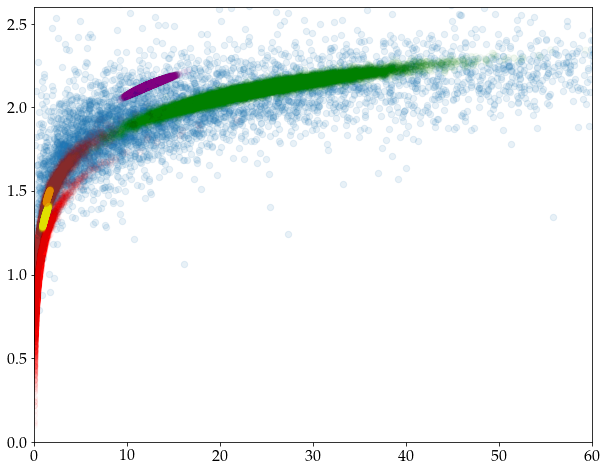

In [302]:
from interp import histogram_weight_2d

xlim = [0.0, 60.0]
ylim = [0.0, 2.5]
Nx, Ny = 100, 100
xg = np.linspace(xlim[0],xlim[1],Nx+1)
yg = np.linspace(ylim[0],ylim[1],Ny+1)

gpr_sample = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
histw, wgk = histogram_weight_2d(np.exp(gpr_sample[:,0]),gpr_sample[:,1],Nx,Ny,xlim,ylim)
wg += [np.copy(wgk)]
gpr_sample = np.append(gpr_sample, histw[...,None], axis=1)

names = ['Chutjian','Filipovic','Khakoo','Schappe','BSR','All']

YG, XG = np.meshgrid(yg,xg)

flat_samples = []
wg = []
for k in range(6):
    temp = np.fromfile('../crs-Bayes-individual/%s.1s3.dat' % names[k])
    temp = np.reshape(temp, [int(len(temp)/2), 2])
    histw, wgk = histogram_weight_2d(temp[:,0],temp[:,1],Nx,Ny,xlim,ylim)
    wg += [np.copy(wgk)]
    temp = np.append(temp, histw[...,None], axis=1)
    flat_samples += [temp]
    
plt.figure(6)
plt.scatter(np.exp(gpr_sample[:,0]), gpr_sample[:,1],s=40.0, alpha=0.1)
for k in range(6):
    plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0, c=flat_samples[k][:,2],label=names[k], cmap='colorMap%d' % k)

# plt.scatter(np.exp(gpr_sample[:,0]), gpr_sample[:,1],s=40.0, c=gpr_sample[:,4], alpha=0.1)
# plt.pcolor(XG,YG,wg[-1],edgecolor='none',cmap='BlueAlphaMap')
# plt.pcolor(XG,YG,np.ones([Nx+1,Ny+1]),alpha=wg[-1]/np.amax(wg[-1]),edgecolor='none')
# plt.xscale('log')
plt.xlim([0, 60])
plt.ylim([0, 2.6])
# plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)

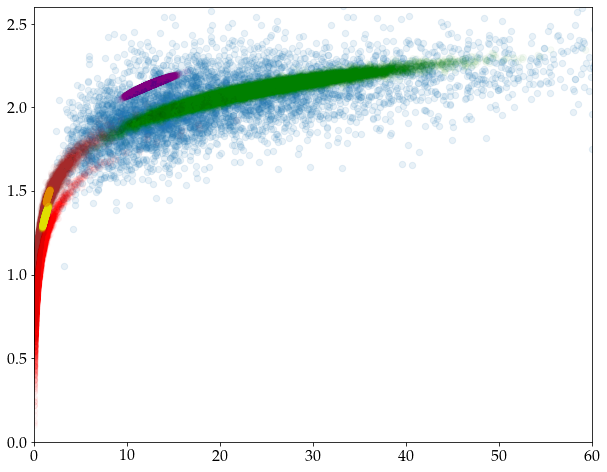

In [296]:
from interp import histogram_weight_2d

xlim = [0.0, 60.0]
ylim = [0.0, 2.5]
Nx, Ny = 100, 100
xg = np.linspace(xlim[0],xlim[1],Nx+1)
yg = np.linspace(ylim[0],ylim[1],Ny+1)

gpr_sample = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
histw, wgk = histogram_weight_2d((gpr_sample[:,0]),gpr_sample[:,1],Nx,Ny,xlim,ylim)
wg += [np.copy(wgk)]
gpr_sample = np.append(gpr_sample, histw[...,None], axis=1)

names = ['Chutjian','Filipovic','Khakoo','Schappe','BSR','All']

YG, XG = np.meshgrid(yg,xg)

flat_samples = []
wg = []
for k in range(6):
    temp = np.fromfile('../crs-Bayes-individual/%s.1s3.dat' % names[k])
    temp = np.reshape(temp, [int(len(temp)/2), 2])
    histw, wgk = histogram_weight_2d(temp[:,0],temp[:,1],Nx,Ny,xlim,ylim)
    wg += [np.copy(wgk)]
    temp = np.append(temp, histw[...,None], axis=1)
    flat_samples += [temp]
    
plt.figure(6)
plt.scatter((gpr_sample[:,0]), gpr_sample[:,1],s=40.0, alpha=0.1)
for k in range(6):
    plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0, c=flat_samples[k][:,2],label=names[k], cmap='colorMap%d' % k)

# plt.scatter(np.exp(gpr_sample[:,0]), gpr_sample[:,1],s=40.0, c=gpr_sample[:,4], alpha=0.1)
# plt.pcolor(XG,YG,wg[-1],edgecolor='none',cmap='BlueAlphaMap')
# plt.pcolor(XG,YG,np.ones([Nx+1,Ny+1]),alpha=wg[-1]/np.amax(wg[-1]),edgecolor='none')
# plt.xscale('log')
plt.xlim([0, 60])
plt.ylim([0, 2.6])
# plt.axis('off')
fig = plt.gcf()
fig.set_size_inches(10, 8)

# 2-level Bayesian

In [328]:
flat_samples = []
minSample = 1e6
for k in range(6):
    temp = np.fromfile('../crs-Bayes-individual/%s.1s3.dat' % names[k])
    temp = np.reshape(temp, [int(len(temp)/2), 2])
    minSample = min(minSample, temp.shape[0])
    flat_samples += [temp]
print(minSample)

3360


In [342]:
nParams = 2
nDatasets = len(Wlog)
minSample = 100

from models import *
import scipy.sparse as sps
from scipy.linalg import cho_factor, cho_solve, LinAlgError

def log_prior(theta):
    paramMeans = theta[:nParams]
    temp = theta[nParams:]
    paramCov = np.zeros([nParams, nParams])
    idx = 0
    for k in range(nParams):
        length = nParams - k
        paramCov[k, k:] = temp[idx:(idx + length)]
        paramCov[k:, k] = paramCov[k, k:]
        idx += length

    theta_ref = np.array([10.4e0, 2.0])

    lp = 0.
    maxError = 1.0e2
    minError = 1.0e-2
    maxError = np.log(1.0 + maxError)
    minError = np.log(1.0 + minError)

    if (paramMeans[0] <= 0.0): return -np.inf
    
    try:
        Lkb, low = cho_factor(paramCov)
    except LinAlgError:
        return - np.inf
    except:
        print(paramCov)
        raise RuntimeError('something else happened.')
    
    if ((paramMeans[0]<=0.0) or (paramMeans[1]<0.0)):
        return - np.inf
    if ((Lkb[0,0] <= 1.0e-2) or (Lkb[0,0] >=1.0e2)):
        return - np.inf
    if ((Lkb[1,1] <= 1.0e-3) or (Lkb[1,1] >=1.0e1)):
        return - np.inf

    sigma2 = ( 1.0 * theta_ref )**2
    lp = - 0.5 * np.sum( (paramMeans - theta_ref)**2 / sigma2 + np.log(2.0*np.pi*sigma2) )
        
    return lp

def log_likelihood(theta):
    # compute log-normal probability
    paramMeans = theta[:nParams]
    temp = theta[nParams:]
    paramCov = np.zeros([nParams, nParams])
    idx = 0
    for k in range(nParams):
        length = nParams - k
        paramCov[k, k:] = temp[idx:(idx + length)]
        paramCov[k:, k] = paramCov[k, k:]
        idx += length
    
    try:
        Lkb, low = cho_factor(paramCov)
    except LinAlgError:
        return - np.inf
    except:
        print(paramCov)
        raise RuntimeError('something else happened.')
        

    
    lk = 0.0
    for k, flatSamplek in enumerate(flat_samples):
        inds = np.random.randint(len(flatSamplek), size=minSample)
        sampleParams = flatSamplek[inds]
        dev = sampleParams.T
        for ss in range(minSample):
            dev[:, ss] -= paramMeans
        try:
            cov_inv_y = cho_solve((Lkb, low), dev)
        except:
            return - np.inf
        temp = -0.5 * np.sum(np.matmul(dev.T, cov_inv_y)) - minSample * np.sum(np.log(Lkb.diagonal())) - 0.5 * nParams * minSample * np.log(2.0 * np.pi)
        lk += temp
    return lk

def log_posterior(theta):
    lp = log_prior(theta)
    lk = log_likelihood(theta)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [343]:
import emcee
nwalkers = 32
theta_ref = np.array([(10.4e0),2.0,10.4,0.1,2.0])
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.5 * np.random.randn(nwalkers,ndim) )
# pos[:16,0] *= 3.0
# pos[:,-1] = 1.0 * np.random.randn(nwalkers)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior
)

In [345]:
sampler.run_mcmc(pos, 1);

for k in range(10):
    sampler.run_mcmc(None, 5000, progress=True);
    tau = sampler.get_autocorr_time(tol=0)
    print(np.amax(tau) / sampler.backend.iteration)

100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:04<00:00, 77.91it/s]


0.09271160832081432


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:05<00:00, 76.69it/s]


0.10936950272523267


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:04<00:00, 77.55it/s]


...

0.0696089729294285


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:04<00:00, 77.55it/s]


0.06508311931478769


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:04<00:00, 77.61it/s]


0.06104448779497093


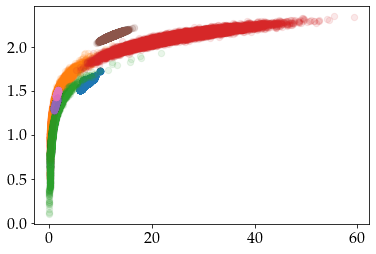

<Figure size 432x288 with 0 Axes>

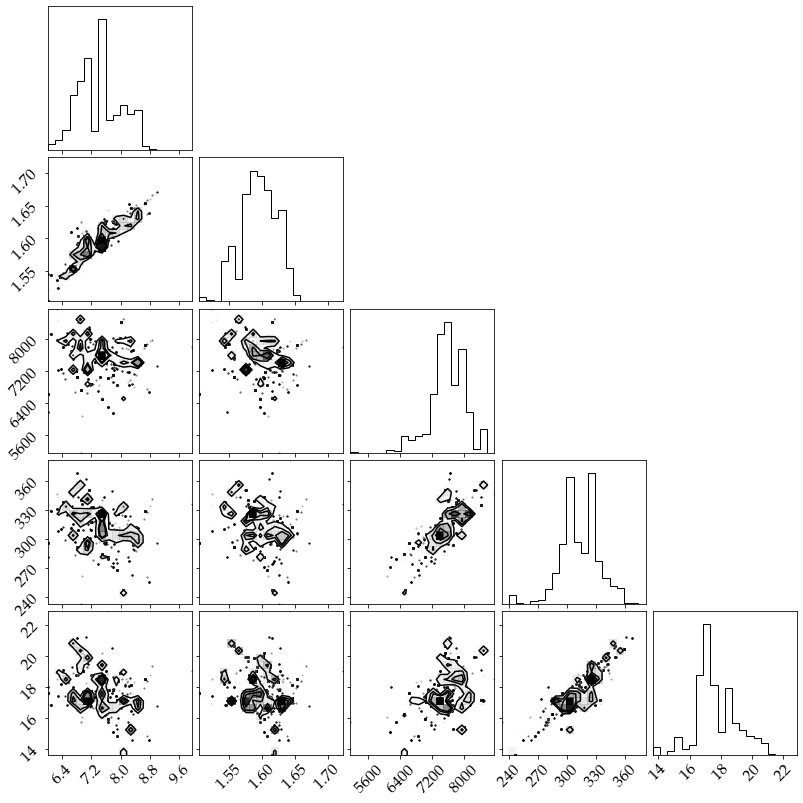

In [355]:
hyper_sample = sampler.get_chain(discard=2*int(max(tau)), thin=int(0.5*min(tau)), flat=True)
hyper_sample.tofile('../crs-Bayes-2level/crs.excitation.1s3.hyper_level_Bayes.dat')

plt.figure(1)
plt.scatter((hyper_sample[:,0]), hyper_sample[:,1],s=40.0, alpha=1.0)
for k in range(6):
    plt.scatter(flat_samples[k][:,0], flat_samples[k][:,1], s=40.0,label=names[k], cmap='colorMap%d' % k, alpha=0.1)
    
plt.figure(2)
import corner
fig = corner.corner(hyper_sample);